# DataJam Bogotá 2026 · Notebook reproducible VIF 2018-2025

Este notebook documenta el procesamiento que respalda el visor HTML de violencia intrafamiliar. La idea es que el jurado o una auditoría técnica pueda ver la cocina completa, no solo el plato servido.

## Qué demuestra

1. Carga y normalización de fuentes.
2. Integración territorial por localidad y periodo.
3. Cálculo de casos, tasas, persistencia, índices y brechas.
4. Validaciones de consistencia frente al visor HTML.
5. Pruebas estadísticas exploratorias: Spearman, Kendall, Pearson y bootstrap.
6. Exportación de la base integrada, resultados estadísticos y HTML actualizado.

## Principio metodológico

Las fuentes no se suman. VIF, lesiones personales y consumo abusivo de SPA representan fenómenos distintos. La integración se hace por indicadores territoriales comparables, no por mezcla de registros. Las pruebas estadísticas se interpretan como asociación territorial exploratoria, no como causalidad.

## 0. Instalación y librerías

En Google Colab normalmente `pandas`, `numpy`, `scipy` y `matplotlib` ya están disponibles. `openpyxl` se usa para leer archivos Excel.

In [1]:
# En Colab, descomentar si hace falta:
# !pip install openpyxl scipy matplotlib pandas numpy

import json
import re
import unicodedata
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
from scipy.stats import spearmanr, kendalltau, pearsonr
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)

ANIO_INICIO = 2018
ANIO_FIN = 2025
ANIOS_ANALISIS = ANIO_FIN - ANIO_INICIO + 1
ESPERADO_TOTAL_VIF_VISOR = 283_773

print(f"Ventana de análisis: {ANIO_INICIO}-{ANIO_FIN} ({ANIOS_ANALISIS} años)")

Ventana de análisis: 2018-2025 (8 años)


## 1. Configuración de carpetas y carga de archivos

Estructura sugerida para Colab o repositorio:

```text
/data
  Violencia intrafamiliar.csv
  lesiones personales.csv
  osb_saludmental_-consumoabusivo_spageneral.xlsx
  obs_prevalenciaconsumospa.xlsx
  poblacion_localidades.csv
/outputs
  base_integrada_localidad_2018_2025.csv
  resultados_pruebas_estadisticas.csv
  index.html
```

También se puede subir el HTML final para auditar que el visor no tenga JSON duplicado y que los datos embebidos coincidan con la base integrada.

In [2]:
# En Colab, puedes subir archivos manualmente con esta celda.
# Déjala comentada si trabajas desde Drive o desde un repositorio.

# from google.colab import files
# uploaded = files.upload()

# Para usar Google Drive:
# from google.colab import drive
# drive.mount('/content/drive')

In [3]:
# Carpeta base flexible: funciona en Colab, local o sandbox.
if Path("/content").exists():
    BASE_DIR = Path("/content")
elif Path("/mnt/data").exists():
    BASE_DIR = Path("/mnt/data")
else:
    BASE_DIR = Path.cwd()

DATA_DIR = BASE_DIR / "data"
OUTPUT_DIR = BASE_DIR / "outputs"
OUTPUT_DIR.mkdir(exist_ok=True)

print("BASE_DIR:", BASE_DIR)
print("DATA_DIR:", DATA_DIR)
print("OUTPUT_DIR:", OUTPUT_DIR)

BASE_DIR: /mnt/data
DATA_DIR: /mnt/data/data
OUTPUT_DIR: /mnt/data/outputs


## 2. Diccionario territorial y funciones de normalización

La integración territorial exige nombres comparables. Por eso se normalizan tildes, mayúsculas, espacios y variantes frecuentes.

In [4]:
LOCALIDADES_CANONICAS = [
    "Usaquén", "Chapinero", "Santa Fe", "San Cristóbal", "Usme", "Tunjuelito", "Bosa", "Kennedy",
    "Fontibón", "Engativá", "Suba", "Barrios Unidos", "Teusaquillo", "Los Mártires", "Antonio Nariño",
    "Puente Aranda", "La Candelaria", "Rafael Uribe Uribe", "Ciudad Bolívar", "Sumapaz"
]

def quitar_tildes(texto):
    if pd.isna(texto):
        return ""
    texto = str(texto).strip()
    texto = unicodedata.normalize("NFKD", texto)
    texto = "".join([c for c in texto if not unicodedata.combining(c)])
    return texto

LOCALIDAD_MAP = {quitar_tildes(x).upper(): x for x in LOCALIDADES_CANONICAS}
LOCALIDAD_ALIASES = {
    "USAQUEN": "Usaquén",
    "SAN CRISTOBAL": "San Cristóbal",
    "CIUDAD BOLIVAR": "Ciudad Bolívar",
    "LOS MARTIRES": "Los Mártires",
    "ANTONIO NARINO": "Antonio Nariño",
    "FONTIBON": "Fontibón",
    "ENGATIVA": "Engativá",
    "BOGOTA": None,
    "DISTRITO": None,
    "SIN LOCALIZACION": None,
    "SIN LOCALIZACIÓN": None,
    "NO LOCALIZADO": None,
    "NO LOCALIZADA": None,
}
LOCALIDAD_MAP.update(LOCALIDAD_ALIASES)

VALIDAS_NORM = {quitar_tildes(x).upper() for x in LOCALIDADES_CANONICAS}

def normalizar_localidad(valor):
    clave = quitar_tildes(valor).upper()
    clave = re.sub(r"\s+", " ", clave).strip()
    if clave in LOCALIDAD_MAP:
        return LOCALIDAD_MAP[clave]
    return None

def normalizar_nombre_columna(col):
    col = quitar_tildes(col).lower()
    col = re.sub(r"[^a-z0-9]+", "_", col).strip("_")
    return col

print(pd.DataFrame({"localidad": LOCALIDADES_CANONICAS, "loc_norm": [quitar_tildes(x).upper() for x in LOCALIDADES_CANONICAS]}))

             localidad            loc_norm
0              Usaquén             USAQUEN
1            Chapinero           CHAPINERO
2             Santa Fe            SANTA FE
3        San Cristóbal       SAN CRISTOBAL
4                 Usme                USME
5           Tunjuelito          TUNJUELITO
6                 Bosa                BOSA
7              Kennedy             KENNEDY
8             Fontibón            FONTIBON
9             Engativá            ENGATIVA
10                Suba                SUBA
11      Barrios Unidos      BARRIOS UNIDOS
12         Teusaquillo         TEUSAQUILLO
13        Los Mártires        LOS MARTIRES
14      Antonio Nariño      ANTONIO NARINO
15       Puente Aranda       PUENTE ARANDA
16       La Candelaria       LA CANDELARIA
17  Rafael Uribe Uribe  RAFAEL URIBE URIBE
18      Ciudad Bolívar      CIUDAD BOLIVAR
19             Sumapaz             SUMAPAZ


## 3. Localización automática de archivos

El notebook intenta encontrar las fuentes por nombre. Si cambian los nombres, basta con ajustar los patrones.

In [5]:
PATRONES_ARCHIVOS = {
    "vif": ["*violencia*intrafamiliar*.csv", "*violencia*intrafamiliar*.xlsx", "*vif*.csv", "*vif*.xlsx"],
    "lesiones": ["*lesiones*personales*.csv", "*lesiones*personales*.xlsx", "*lesiones*.csv", "*lesiones*.xlsx"],
    "spa_abusivo": ["*consumoabusivo*.xlsx", "*consumo*abusivo*.xlsx", "*saludmental*spa*.xlsx", "*spa*general*.xlsx"],
    "prevalencia_spa": ["*prevalencia*consumo*spa*.xlsx", "*prevalenciaconsumospa*.xlsx", "*prevalencia*.xlsx"],
    "poblacion": ["*poblacion*local*.csv", "*poblacion*local*.xlsx", "*proyeccion*poblacion*.xlsx"],
    "html": ["index*.html", "reporte*grafico*.html", "reporte*VIF*.html", "*.html"]
}

def buscar_archivo(patrones, carpetas=(BASE_DIR, DATA_DIR)):
    candidatos = []
    for carpeta in carpetas:
        if not carpeta.exists():
            continue
        for patron in patrones:
            candidatos.extend(sorted(carpeta.glob(patron)))
    # Evita duplicados preservando orden
    vistos = set()
    unicos = []
    for p in candidatos:
        if p.resolve() not in vistos:
            unicos.append(p)
            vistos.add(p.resolve())
    return unicos[0] if unicos else None

ARCHIVOS = {k: buscar_archivo(v) for k, v in PATRONES_ARCHIVOS.items()}
pd.DataFrame([{"fuente": k, "archivo_detectado": str(v) if v else "NO ENCONTRADO"} for k, v in ARCHIVOS.items()])

,fuente,archivo_detectado
0,vif,NO ENCONTRADO
1,lesiones,NO ENCONTRADO
2,spa_abusivo,NO ENCONTRADO
3,prevalencia_spa,NO ENCONTRADO
4,poblacion,NO ENCONTRADO
5,html,/mnt/data/index (1028).html


## 4. Funciones de lectura flexible

Estas funciones permiten leer CSV y Excel, detectar columnas probables y preparar datos aunque los nombres de columnas no sean idénticos entre fuentes.

In [6]:
def leer_tabla(ruta):
    ruta = Path(ruta)
    if not ruta.exists():
        raise FileNotFoundError(ruta)
    suf = ruta.suffix.lower()
    if suf in [".xlsx", ".xls"]:
        return pd.read_excel(ruta)
    if suf == ".csv":
        for enc in ["utf-8", "utf-8-sig", "latin-1", "cp1252"]:
            try:
                return pd.read_csv(ruta, encoding=enc)
            except UnicodeDecodeError:
                continue
        return pd.read_csv(ruta)
    raise ValueError(f"Formato no soportado: {ruta.suffix}")

def detectar_columna(df, candidatos, obligatoria=False):
    cols_norm = {normalizar_nombre_columna(c): c for c in df.columns}
    candidatos_norm = [normalizar_nombre_columna(c) for c in candidatos]

    # Coincidencia exacta
    for cand in candidatos_norm:
        if cand in cols_norm:
            return cols_norm[cand]

    # Coincidencia parcial
    for cand in candidatos_norm:
        for cn, original in cols_norm.items():
            if cand in cn or cn in cand:
                return original

    if obligatoria:
        raise ValueError(f"No se encontró columna. Candidatos: {candidatos}. Columnas disponibles: {list(df.columns)}")
    return None

def extraer_anio(df, col_fecha=None, col_anio=None):
    if col_anio and col_anio in df.columns:
        anio = pd.to_numeric(df[col_anio], errors="coerce")
        return anio.astype("Int64")
    if col_fecha and col_fecha in df.columns:
        fecha = pd.to_datetime(df[col_fecha], errors="coerce", dayfirst=True)
        return fecha.dt.year.astype("Int64")
    return pd.Series([pd.NA] * len(df), index=df.index, dtype="Int64")

def preparar_fuente_eventos(df, nombre_fuente, col_localidad=None, col_fecha=None, col_anio=None, col_conteo=None):
    df = df.copy()
    if col_localidad is None:
        col_localidad = detectar_columna(df, ["localidad", "nom_localidad", "nombre_localidad", "loc", "territorio"], obligatoria=True)
    if col_anio is None:
        col_anio = detectar_columna(df, ["anio", "año", "ano", "vigencia", "year"])
    if col_fecha is None:
        col_fecha = detectar_columna(df, ["fecha", "fecha_hecho", "fecha_ocurrencia", "fecha_registro", "fec_hecho"])
    if col_conteo is None:
        col_conteo = detectar_columna(df, ["casos", "cantidad", "conteo", "total"])

    df["localidad"] = df[col_localidad].apply(normalizar_localidad)
    df["anio"] = extraer_anio(df, col_fecha=col_fecha, col_anio=col_anio)
    df = df[df["localidad"].notna()].copy()
    df = df[df["anio"].between(ANIO_INICIO, ANIO_FIN)].copy()

    if col_conteo and col_conteo in df.columns and pd.api.types.is_numeric_dtype(df[col_conteo]):
        df["conteo_eventos"] = pd.to_numeric(df[col_conteo], errors="coerce").fillna(0)
    else:
        df["conteo_eventos"] = 1

    anual = (
        df.groupby(["localidad", "anio"], as_index=False)["conteo_eventos"]
          .sum()
          .rename(columns={"conteo_eventos": f"{nombre_fuente}_casos"})
    )
    total = (
        anual.groupby("localidad", as_index=False)[f"{nombre_fuente}_casos"]
             .sum()
             .rename(columns={f"{nombre_fuente}_casos": f"{nombre_fuente}_casos_2018_2025"})
    )
    return total, anual

## 5. Funciones específicas para VIF

Además del conteo de casos, VIF requiere dos componentes para el índice:

- Persistencia anual: número de años en que la tasa de VIF de la localidad estuvo por encima de la mediana anual de localidades.
- Participación de mujeres y NNA: proporción de casos registrados en mujeres, niñas, niños y adolescentes, cuando las columnas existen en la fuente.

In [7]:
def calcular_pct_mujeres_nna(df, col_localidad=None, col_sexo=None, col_edad=None, col_curso_vida=None):
    df = df.copy()
    if col_localidad is None:
        col_localidad = detectar_columna(df, ["localidad", "nom_localidad", "nombre_localidad", "loc", "territorio"])
    if not col_localidad:
        return pd.DataFrame(columns=["localidad", "pct_mujeres_nna_vif"])

    col_sexo = col_sexo or detectar_columna(df, ["sexo", "genero", "género"])
    col_edad = col_edad or detectar_columna(df, ["edad", "edad_victima", "edad_persona"])
    col_curso_vida = col_curso_vida or detectar_columna(df, ["curso_vida", "grupo_edad", "ciclo_vital", "rango_edad"])

    df["localidad"] = df[col_localidad].apply(normalizar_localidad)
    df = df[df["localidad"].notna()].copy()

    mujer = pd.Series(False, index=df.index)
    nna = pd.Series(False, index=df.index)

    if col_sexo:
        sexo_norm = df[col_sexo].astype(str).map(lambda x: quitar_tildes(x).upper())
        mujer = sexo_norm.str.contains("MUJER|FEMENINO|FEMENINA|^F$", regex=True, na=False)

    if col_edad:
        edad_num = pd.to_numeric(df[col_edad], errors="coerce")
        nna = edad_num.le(17).fillna(False)

    if col_curso_vida:
        curso = df[col_curso_vida].astype(str).map(lambda x: quitar_tildes(x).upper())
        nna = nna | curso.str.contains("NINO|NINA|ADOLESC|MENOR|INFANCIA|PRIMERA INFANCIA", regex=True, na=False)

    df["es_mujer_o_nna"] = mujer | nna
    resumen = (
        df.groupby("localidad", as_index=False)["es_mujer_o_nna"]
          .mean()
          .rename(columns={"es_mujer_o_nna": "pct_mujeres_nna_vif"})
    )
    resumen["pct_mujeres_nna_vif"] = (resumen["pct_mujeres_nna_vif"] * 100).round(2)
    return resumen

def calcular_persistencia_vif(vif_anual, poblacion_ref):
    tmp = vif_anual.copy()
    tmp = tmp.merge(poblacion_ref[["localidad", "poblacion_ref"]], on="localidad", how="left")
    tmp["tasa_anual_100k"] = tmp["vif_casos"] / tmp["poblacion_ref"] * 100000
    tmp["mediana_anual_localidades"] = tmp.groupby("anio")["tasa_anual_100k"].transform("median")
    tmp["sobre_mediana"] = tmp["tasa_anual_100k"] > tmp["mediana_anual_localidades"]
    persistencia = (
        tmp.groupby("localidad", as_index=False)["sobre_mediana"]
           .sum()
           .rename(columns={"sobre_mediana": "vif_persistencia_anios"})
    )
    persistencia["vif_persistencia_anios"] = persistencia["vif_persistencia_anios"].astype(int)
    return persistencia, tmp

## 6. Datos embebidos del visor como respaldo de auditoría

Esta sección no reemplaza las fuentes originales. Sirve para validar el HTML final: detectar JSON duplicado, revisar totales y comparar los cálculos que aparecen en el visor.

In [8]:
def extraer_json_data_desde_html(html_path):
    html_path = Path(html_path)
    texto = html_path.read_text(encoding="utf-8")
    m = re.search(r"const\s+DATA\s*=\s*(\[.*?\]);", texto, flags=re.S)
    if not m:
        raise ValueError("No se encontró const DATA = [...] en el HTML")
    json_text = m.group(1)
    duplicados = []

    def hook(pairs):
        keys = [k for k, _ in pairs]
        reps = sorted([k for k, v in Counter(keys).items() if v > 1])
        if reps:
            duplicados.append(reps)
        return dict(pairs)

    data = json.loads(json_text, object_pairs_hook=hook)
    df_html = pd.DataFrame(data)
    return df_html, duplicados, json_text

html_path = ARCHIVOS.get("html")
if html_path:
    base_html, duplicados_json, json_text = extraer_json_data_desde_html(html_path)
    print("HTML detectado:", html_path)
    print("Registros en DATA:", len(base_html))
    print("Objetos con claves duplicadas:", len(duplicados_json))
    display(base_html.head())
else:
    base_html = pd.DataFrame()
    duplicados_json = []
    print("No se encontró HTML para auditoría.")

HTML detectado: /mnt/data/index (1028).html
Registros en DATA: 20
Objetos con claves duplicadas: 0


,localidad,loc_norm,poblacion_ref,vif_casos_2018_2025,vif_tasa_prom_anual_100k,vif_persistencia_anios,pct_mujeres_nna_vif,lesiones_casos_2018_2025,lesiones_tasa_prom_anual_100k,spa_abusivo_casos_2018_2025,spa_abusivo_tasa_prom_anual_100k,indice_vif_familiar,indice_contexto,brecha_vif_contexto,rank_vif_carga,rank_vif_tasa,rank_vif_familiar,cambio_carga_vs_tasa,nivel_vif_familiar,nivel_contexto,tipo_decision,alerta_lectura,accion_sugerida,lectura_breve,lectura_breve_final
0,Bosa,BOSA,673077,31314.0,581.55,7,79.53,14132,262.45,5943,110.37,68.28,17.30,50.98,4,4,4,0,alto,bajo,VIF alta con contexto moderado,Baja: lectura territorial más estable.,La prioridad debería estar en rutas de atenció...,"Registra 31.314 casos entre 2018 y 2025, con u...","Registra 31.314 casos entre 2018 y 2025, con u..."
1,Ciudad Bolívar,CIUDAD BOLIVAR,707569,32707.0,577.81,8,80.45,16160,285.48,4909,86.72,74.13,17.31,56.82,3,5,2,-2,alto,bajo,VIF alta con contexto moderado,Baja: lectura territorial más estable.,La prioridad debería estar en rutas de atenció...,"Registra 32.707 casos entre 2018 y 2025, con u...","Registra 32.707 casos entre 2018 y 2025, con u..."
2,San Cristóbal,SAN CRISTOBAL,404697,17723.0,547.42,8,79.32,9979,308.22,2993,92.45,66.32,18.96,47.36,6,6,6,0,alto,bajo,VIF alta con contexto moderado,Baja: lectura territorial más estable.,La prioridad debería estar en rutas de atenció...,"Registra 17.723 casos entre 2018 y 2025, con u...","Registra 17.723 casos entre 2018 y 2025, con u..."
3,Los Mártires,LOS MARTIRES,99119,8819.0,1112.17,8,74.28,6496,819.22,7099,895.26,76.18,94.00,-17.82,12,1,1,11,alto,alto,VIF alta con entorno complejo,Media: posible efecto de población flotante o ...,Conviene revisar la oferta de atención familia...,"Registra 8.819 casos entre 2018 y 2025, con un...","Registra 8.819 casos entre 2018 y 2025, con un..."
4,Usme,USME,457302,15558.0,425.27,6,80.63,9623,263.04,3408,93.16,55.95,16.37,39.58,7,10,7,-3,medio,bajo,Seguimiento focalizado,Baja: lectura territorial más estable.,La VIF pesa más que las señales de contexto. V...,"Registra 15.558 casos entre 2018 y 2025, con u...","Registra 15.558 casos entre 2018 y 2025, con u..."


## 7. Población de referencia

Para tasas por 100.000 habitantes se requiere un denominador poblacional por localidad. En el flujo ideal se carga desde una fuente oficial. Como respaldo, este notebook puede usar la población embebida en el visor, dejando trazabilidad de ese uso.

In [9]:
def cargar_poblacion_ref(archivo_poblacion=None, base_html=None):
    if archivo_poblacion and Path(archivo_poblacion).exists():
        pob = leer_tabla(archivo_poblacion)
        col_loc = detectar_columna(pob, ["localidad", "nom_localidad", "nombre_localidad", "loc"], obligatoria=True)
        col_pob = detectar_columna(pob, ["poblacion_ref", "poblacion", "habitantes", "proyeccion", "total_poblacion"], obligatoria=True)
        pob["localidad"] = pob[col_loc].apply(normalizar_localidad)
        pob["poblacion_ref"] = pd.to_numeric(pob[col_pob], errors="coerce")
        pob = pob[pob["localidad"].notna()].copy()
        return pob.groupby("localidad", as_index=False)["poblacion_ref"].mean()

    if base_html is not None and not base_html.empty and "poblacion_ref" in base_html.columns:
        print("Usando población de referencia embebida en el visor. Documentar esta decisión en la nota técnica.")
        return base_html[["localidad", "poblacion_ref"]].drop_duplicates().copy()

    raise ValueError("No hay archivo de población ni base HTML con población_ref.")

poblacion_ref = cargar_poblacion_ref(ARCHIVOS.get("poblacion"), base_html)
poblacion_ref.sort_values("localidad").head()

Usando población de referencia embebida en el visor. Documentar esta decisión en la nota técnica.


,localidad,poblacion_ref
17,Antonio Nariño,109176
19,Barrios Unidos,243465
0,Bosa,673077
10,Chapinero,139701
1,Ciudad Bolívar,707569


## 8. Construcción de indicadores desde fuentes originales o desde visor validado

Flujo preferido:

1. Procesar VIF, lesiones y SPA desde fuentes originales.
2. Calcular tasas, persistencia, índices y brechas.
3. Comparar con el HTML final.

Cuando las fuentes originales no están cargadas en Colab, el notebook usa el DATA del HTML como base de validación para mostrar las fórmulas y pruebas estadísticas.

In [10]:
def minmax_100(s):
    s = pd.to_numeric(s, errors="coerce")
    if s.max() == s.min():
        return pd.Series(np.zeros(len(s)), index=s.index)
    return (s - s.min()) / (s.max() - s.min()) * 100

def clasificar_nivel_terciles(s):
    q1 = s.quantile(1/3)
    q2 = s.quantile(2/3)
    return pd.cut(s, bins=[-np.inf, q1, q2, np.inf], labels=["bajo", "medio", "alto"]).astype(str)

def construir_indicadores_desde_componentes(base):
    df = base.copy()

    # Tasas promedio anual por 100.000 habitantes
    df["vif_tasa_prom_anual_100k_calc"] = (df["vif_casos_2018_2025"] / df["poblacion_ref"] * 100000 / ANIOS_ANALISIS).round(2)
    df["lesiones_tasa_prom_anual_100k_calc"] = (df["lesiones_casos_2018_2025"] / df["poblacion_ref"] * 100000 / ANIOS_ANALISIS).round(2)
    df["spa_abusivo_tasa_prom_anual_100k_calc"] = (df["spa_abusivo_casos_2018_2025"] / df["poblacion_ref"] * 100000 / ANIOS_ANALISIS).round(2)

    # Si no existen las tasas finales, se crean desde el cálculo
    for col in ["vif_tasa_prom_anual_100k", "lesiones_tasa_prom_anual_100k", "spa_abusivo_tasa_prom_anual_100k"]:
        col_calc = f"{col}_calc"
        if col not in df.columns:
            df[col] = df[col_calc]

    # Índice VIF
    df["tasa_vif_norm"] = minmax_100(df["vif_tasa_prom_anual_100k"])
    df["persistencia_norm"] = minmax_100(df["vif_persistencia_anios"])
    df["mujeres_nna_norm"] = minmax_100(df["pct_mujeres_nna_vif"])
    df["casos_vif_norm"] = minmax_100(df["vif_casos_2018_2025"])

    df["indice_vif_familiar_calc"] = (
        df["tasa_vif_norm"] * 0.40 +
        df["persistencia_norm"] * 0.30 +
        df["mujeres_nna_norm"] * 0.20 +
        df["casos_vif_norm"] * 0.10
    ).round(2)

    # Índice de contexto
    df["lesiones_norm"] = minmax_100(df["lesiones_tasa_prom_anual_100k"])
    df["spa_norm"] = minmax_100(df["spa_abusivo_tasa_prom_anual_100k"])
    df["indice_contexto_calc"] = (df["lesiones_norm"] * 0.50 + df["spa_norm"] * 0.50).round(2)

    # Si el HTML no traía índices, los adopta. Si los traía, se conservan y se comparan.
    if "indice_vif_familiar" not in df.columns:
        df["indice_vif_familiar"] = df["indice_vif_familiar_calc"]
    if "indice_contexto" not in df.columns:
        df["indice_contexto"] = df["indice_contexto_calc"]

    df["brecha_vif_contexto_calc"] = (df["indice_vif_familiar"] - df["indice_contexto"]).round(2)
    if "brecha_vif_contexto" not in df.columns:
        df["brecha_vif_contexto"] = df["brecha_vif_contexto_calc"]

    # Rankings y niveles
    df["rank_vif_carga_calc"] = df["vif_casos_2018_2025"].rank(method="dense", ascending=False).astype(int)
    df["rank_vif_tasa_calc"] = df["vif_tasa_prom_anual_100k"].rank(method="dense", ascending=False).astype(int)
    df["rank_vif_familiar_calc"] = df["indice_vif_familiar"].rank(method="dense", ascending=False).astype(int)

    if "nivel_vif_familiar" not in df.columns:
        df["nivel_vif_familiar"] = clasificar_nivel_terciles(df["indice_vif_familiar"])
    if "nivel_contexto" not in df.columns:
        df["nivel_contexto"] = clasificar_nivel_terciles(df["indice_contexto"])

    return df

In [11]:
FUENTES_RAW_COMPLETAS = all(ARCHIVOS.get(k) is not None for k in ["vif", "lesiones", "spa_abusivo"])

if FUENTES_RAW_COMPLETAS:
    print("Modo de procesamiento: FUENTES ORIGINALES")

    # VIF
    vif_raw = leer_tabla(ARCHIVOS["vif"])
    vif_total, vif_anual = preparar_fuente_eventos(vif_raw, "vif")
    pct_vif = calcular_pct_mujeres_nna(vif_raw)

    # Lesiones personales
    lesiones_raw = leer_tabla(ARCHIVOS["lesiones"])
    lesiones_total, lesiones_anual = preparar_fuente_eventos(lesiones_raw, "lesiones")

    # Consumo abusivo SPA
    spa_raw = leer_tabla(ARCHIVOS["spa_abusivo"])
    spa_total, spa_anual = preparar_fuente_eventos(spa_raw, "spa_abusivo")

    # Renombrar columnas para consistencia
    vif_total = vif_total.rename(columns={"vif_casos_2018_2025": "vif_casos_2018_2025"})
    lesiones_total = lesiones_total.rename(columns={"lesiones_casos_2018_2025": "lesiones_casos_2018_2025"})
    spa_total = spa_total.rename(columns={"spa_abusivo_casos_2018_2025": "spa_abusivo_casos_2018_2025"})

    # Persistencia anual VIF
    persistencia, vif_anual_con_tasas = calcular_persistencia_vif(vif_anual, poblacion_ref)

    base_integrada = (
        poblacion_ref
        .merge(vif_total, on="localidad", how="left")
        .merge(lesiones_total, on="localidad", how="left")
        .merge(spa_total, on="localidad", how="left")
        .merge(persistencia, on="localidad", how="left")
        .merge(pct_vif, on="localidad", how="left")
    )

    for col in ["vif_casos_2018_2025", "lesiones_casos_2018_2025", "spa_abusivo_casos_2018_2025", "vif_persistencia_anios"]:
        base_integrada[col] = base_integrada[col].fillna(0)
    base_integrada["pct_mujeres_nna_vif"] = base_integrada["pct_mujeres_nna_vif"].fillna(base_integrada["pct_mujeres_nna_vif"].median())

    base_integrada = construir_indicadores_desde_componentes(base_integrada)
    MODO_PROCESAMIENTO = "fuentes_originales"

else:
    print("Modo de procesamiento: DATA embebido del HTML validado")
    print("Nota: para entrega final, cargar las fuentes originales en /data y reejecutar esta misma libreta.")
    if base_html.empty:
        raise ValueError("No hay fuentes originales ni HTML. Sube los datos o el HTML final.")
    base_integrada = construir_indicadores_desde_componentes(base_html)
    MODO_PROCESAMIENTO = "html_validado"

base_integrada = base_integrada.sort_values("indice_vif_familiar", ascending=False).reset_index(drop=True)
display(base_integrada[["localidad", "vif_casos_2018_2025", "vif_tasa_prom_anual_100k", "vif_persistencia_anios", "indice_vif_familiar", "indice_contexto", "brecha_vif_contexto"]])

Modo de procesamiento: DATA embebido del HTML validado
Nota: para entrega final, cargar las fuentes originales en /data y reejecutar esta misma libreta.


,localidad,vif_casos_2018_2025,vif_tasa_prom_anual_100k,vif_persistencia_anios,indice_vif_familiar,indice_contexto,brecha_vif_contexto
0,Los Mártires,8819.0,1112.17,8,76.18,94.00,-17.82
1,Ciudad Bolívar,32707.0,577.81,8,74.13,17.31,56.82
2,La Candelaria,2128.0,1104.28,8,70.28,97.33,-27.05
3,Bosa,31314.0,581.55,7,68.28,17.30,50.98
4,Santa Fe,7813.0,887.45,8,68.21,69.66,-1.45
5,San Cristóbal,17723.0,547.42,8,66.32,18.96,47.36
6,Usme,15558.0,425.27,6,55.95,16.37,39.58
7,Kennedy,34615.0,397.53,3,46.76,14.46,32.30
8,Tunjuelito,7002.0,438.88,4,40.65,21.90,18.75
9,Rafael Uribe Uribe,12593.0,420.61,3,39.72,19.34,20.38


## 9. Validaciones de calidad y consistencia

Estas validaciones son las que deberían aparecer en una auditoría:

- 20 localidades válidas.
- Sin localidades duplicadas.
- Sin persistencia mayor a 8 años.
- Total VIF esperado en el visor.
- Tasas recalculadas desde casos, población y años.
- Índices recalculados desde la fórmula documentada.
- JSON del HTML sin claves duplicadas.

In [12]:
def validar_base_integrada(df):
    checks = []

    checks.append({"validacion": "Número de localidades", "valor": len(df), "esperado": 20, "ok": len(df) == 20})
    checks.append({"validacion": "Localidades únicas", "valor": df["localidad"].nunique(), "esperado": len(df), "ok": df["localidad"].nunique() == len(df)})
    checks.append({"validacion": "Sin casos VIF negativos", "valor": int((df["vif_casos_2018_2025"] < 0).sum()), "esperado": 0, "ok": bool((df["vif_casos_2018_2025"] >= 0).all())})
    checks.append({"validacion": "Persistencia máxima <= 8", "valor": int(df["vif_persistencia_anios"].max()), "esperado": "<= 8", "ok": bool(df["vif_persistencia_anios"].max() <= ANIOS_ANALISIS)})
    checks.append({"validacion": "Persistencia mínima >= 0", "valor": int(df["vif_persistencia_anios"].min()), "esperado": ">= 0", "ok": bool(df["vif_persistencia_anios"].min() >= 0)})
    checks.append({"validacion": "Total VIF visor", "valor": int(round(df["vif_casos_2018_2025"].sum())), "esperado": ESPERADO_TOTAL_VIF_VISOR, "ok": int(round(df["vif_casos_2018_2025"].sum())) == ESPERADO_TOTAL_VIF_VISOR})
    checks.append({"validacion": "JSON sin claves duplicadas", "valor": len(duplicados_json), "esperado": 0, "ok": len(duplicados_json) == 0})

    # Diferencias de cálculo
    checks.append({"validacion": "Diferencia máxima tasa VIF", "valor": float((df["vif_tasa_prom_anual_100k"] - df["vif_tasa_prom_anual_100k_calc"]).abs().max()), "esperado": "<= 0.05", "ok": bool((df["vif_tasa_prom_anual_100k"] - df["vif_tasa_prom_anual_100k_calc"]).abs().max() <= 0.05)})
    checks.append({"validacion": "Diferencia máxima índice VIF", "valor": float((df["indice_vif_familiar"] - df["indice_vif_familiar_calc"]).abs().max()), "esperado": "<= 0.05", "ok": bool((df["indice_vif_familiar"] - df["indice_vif_familiar_calc"]).abs().max() <= 0.05)})
    checks.append({"validacion": "Diferencia máxima índice contexto", "valor": float((df["indice_contexto"] - df["indice_contexto_calc"]).abs().max()), "esperado": "<= 0.05", "ok": bool((df["indice_contexto"] - df["indice_contexto_calc"]).abs().max() <= 0.05)})

    return pd.DataFrame(checks)

validaciones = validar_base_integrada(base_integrada)
display(validaciones)

if not validaciones["ok"].all():
    print("Hay validaciones para revisar antes de entrega:")
    display(validaciones[~validaciones["ok"]])
else:
    print("Todas las validaciones principales pasaron.")

,validacion,valor,esperado,ok
0,Número de localidades,20.00,20,True
1,Localidades únicas,20.00,20,True
2,Sin casos VIF negativos,0.00,0,True
3,Persistencia máxima <= 8,8.00,<= 8,True
4,Persistencia mínima >= 0,0.00,>= 0,True
5,Total VIF visor,283773.00,283773,True
6,JSON sin claves duplicadas,0.00,0,True
7,Diferencia máxima tasa VIF,0.00,<= 0.05,True
8,Diferencia máxima índice VIF,0.02,<= 0.05,True
9,Diferencia máxima índice contexto,0.00,<= 0.05,True


Todas las validaciones principales pasaron.


## 10. Pruebas estadísticas exploratorias

Con 20 localidades, las pruebas deben ser prudentes. Se usan correlaciones no paramétricas para evaluar asociación territorial, no causalidad.

- **Spearman:** asociación monotónica entre rankings o valores no necesariamente normales.
- **Kendall:** prueba de sensibilidad útil con pocos registros.
- **Pearson:** referencia lineal, no se usa como única evidencia.
- **Bootstrap:** intervalo de confianza empírico para Spearman.

In [13]:
def bootstrap_spearman_ci(x, y, n_boot=5000, ci=95, random_state=42):
    rng = np.random.default_rng(random_state)
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    mask = np.isfinite(x) & np.isfinite(y)
    x = x[mask]
    y = y[mask]
    n = len(x)
    vals = []
    for _ in range(n_boot):
        idx = rng.integers(0, n, size=n)
        # Si el remuestreo deja una variable constante, se omite.
        if len(np.unique(x[idx])) < 2 or len(np.unique(y[idx])) < 2:
            continue
        vals.append(spearmanr(x[idx], y[idx]).statistic)
    vals = np.array(vals)
    alpha = (100 - ci) / 2
    return np.nanpercentile(vals, alpha), np.nanpercentile(vals, 100 - alpha)

def interpretar_pvalor(p):
    if p < 0.05:
        return "asociación estadísticamente significativa al 5%"
    if p < 0.10:
        return "asociación marginal; interpretar con cautela"
    return "no se observa asociación estadísticamente significativa"

def fuerza_correlacion(r):
    ar = abs(r)
    if ar >= 0.70:
        return "alta"
    if ar >= 0.40:
        return "moderada"
    if ar >= 0.20:
        return "baja"
    return "muy baja"

pruebas = [
    ("Índice VIF vs índice contexto", "indice_vif_familiar", "indice_contexto"),
    ("Tasa VIF vs tasa lesiones", "vif_tasa_prom_anual_100k", "lesiones_tasa_prom_anual_100k"),
    ("Tasa VIF vs tasa SPA abusivo", "vif_tasa_prom_anual_100k", "spa_abusivo_tasa_prom_anual_100k"),
    ("Índice VIF vs tasa lesiones", "indice_vif_familiar", "lesiones_tasa_prom_anual_100k"),
    ("Índice VIF vs tasa SPA abusivo", "indice_vif_familiar", "spa_abusivo_tasa_prom_anual_100k"),
]

resultados = []
for nombre, xcol, ycol in pruebas:
    sub = base_integrada[["localidad", xcol, ycol]].dropna().copy()
    x = sub[xcol].astype(float)
    y = sub[ycol].astype(float)

    sp = spearmanr(x, y)
    kd = kendalltau(x, y)
    pe = pearsonr(x, y)
    ci_low, ci_high = bootstrap_spearman_ci(x, y)

    resultados.append({
        "prueba": nombre,
        "x": xcol,
        "y": ycol,
        "n_localidades": len(sub),
        "spearman_rho": round(float(sp.statistic), 3),
        "spearman_p_value": round(float(sp.pvalue), 5),
        "spearman_ci95_inf_bootstrap": round(float(ci_low), 3),
        "spearman_ci95_sup_bootstrap": round(float(ci_high), 3),
        "kendall_tau": round(float(kd.statistic), 3),
        "kendall_p_value": round(float(kd.pvalue), 5),
        "pearson_r": round(float(pe.statistic), 3),
        "pearson_p_value": round(float(pe.pvalue), 5),
        "fuerza_spearman": fuerza_correlacion(float(sp.statistic)),
        "interpretacion": interpretar_pvalor(float(sp.pvalue)),
    })

resultados_estadisticos = pd.DataFrame(resultados)
display(resultados_estadisticos)

,prueba,x,y,n_localidades,spearman_rho,spearman_p_value,spearman_ci95_inf_bootstrap,spearman_ci95_sup_bootstrap,kendall_tau,kendall_p_value,pearson_r,pearson_p_value,fuerza_spearman,interpretacion
0,Índice VIF vs índice contexto,indice_vif_familiar,indice_contexto,20,0.549,0.01220,0.080,0.831,0.400,0.01353,0.615,0.00388,moderada,asociación estadísticamente significativa al 5%
1,Tasa VIF vs tasa lesiones,vif_tasa_prom_anual_100k,lesiones_tasa_prom_anual_100k,20,0.797,0.00003,0.458,0.940,0.611,0.00007,0.952,0.00000,alta,asociación estadísticamente significativa al 5%
2,Tasa VIF vs tasa SPA abusivo,vif_tasa_prom_anual_100k,spa_abusivo_tasa_prom_anual_100k,20,0.734,0.00023,0.327,0.935,0.589,0.00014,0.931,0.00000,alta,asociación estadísticamente significativa al 5%
3,Índice VIF vs tasa lesiones,indice_vif_familiar,lesiones_tasa_prom_anual_100k,20,0.553,0.01137,0.103,0.824,0.389,0.01641,0.646,0.00208,moderada,asociación estadísticamente significativa al 5%
4,Índice VIF vs tasa SPA abusivo,indice_vif_familiar,spa_abusivo_tasa_prom_anual_100k,20,0.493,0.02711,-0.014,0.812,0.326,0.04677,0.576,0.00790,moderada,asociación estadísticamente significativa al 5%


## 11. Visualizaciones estadísticas de respaldo

Estas gráficas no reemplazan el visor. Funcionan como evidencia técnica dentro del notebook.

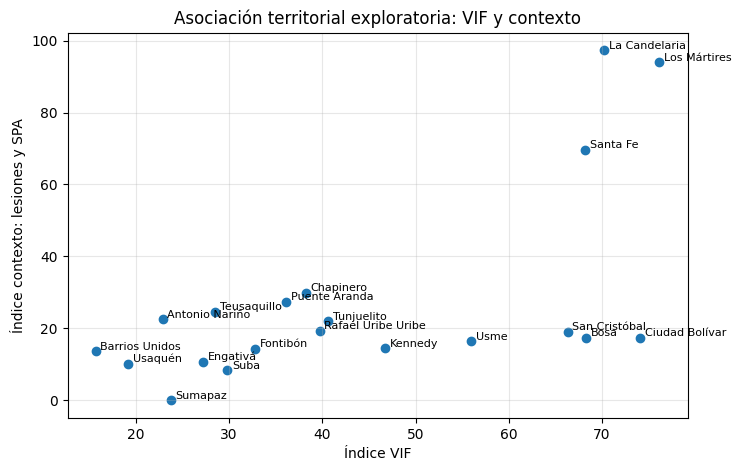

In [14]:
# Gráfico 1: Índice VIF vs índice contexto
plt.figure(figsize=(8, 5))
plt.scatter(base_integrada["indice_vif_familiar"], base_integrada["indice_contexto"])
for _, r in base_integrada.iterrows():
    plt.text(r["indice_vif_familiar"] + 0.5, r["indice_contexto"] + 0.5, r["localidad"], fontsize=8)
plt.xlabel("Índice VIF")
plt.ylabel("Índice contexto: lesiones y SPA")
plt.title("Asociación territorial exploratoria: VIF y contexto")
plt.grid(True, alpha=0.3)
plt.show()

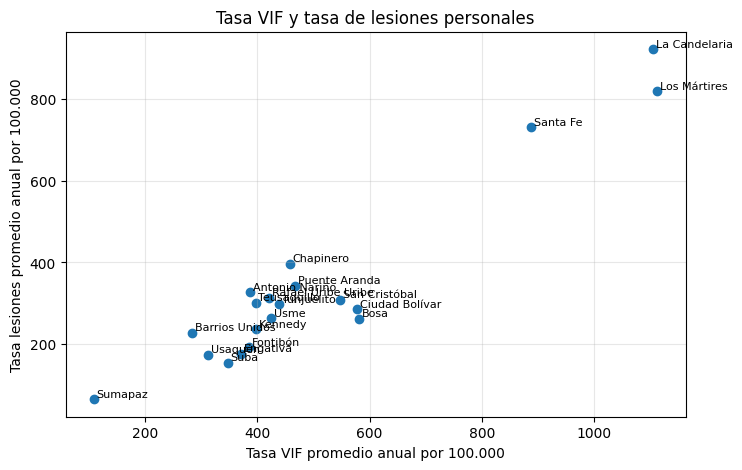

In [15]:
# Gráfico 2: Tasa VIF vs tasa lesiones
plt.figure(figsize=(8, 5))
plt.scatter(base_integrada["vif_tasa_prom_anual_100k"], base_integrada["lesiones_tasa_prom_anual_100k"])
for _, r in base_integrada.iterrows():
    plt.text(r["vif_tasa_prom_anual_100k"] + 5, r["lesiones_tasa_prom_anual_100k"] + 5, r["localidad"], fontsize=8)
plt.xlabel("Tasa VIF promedio anual por 100.000")
plt.ylabel("Tasa lesiones promedio anual por 100.000")
plt.title("Tasa VIF y tasa de lesiones personales")
plt.grid(True, alpha=0.3)
plt.show()

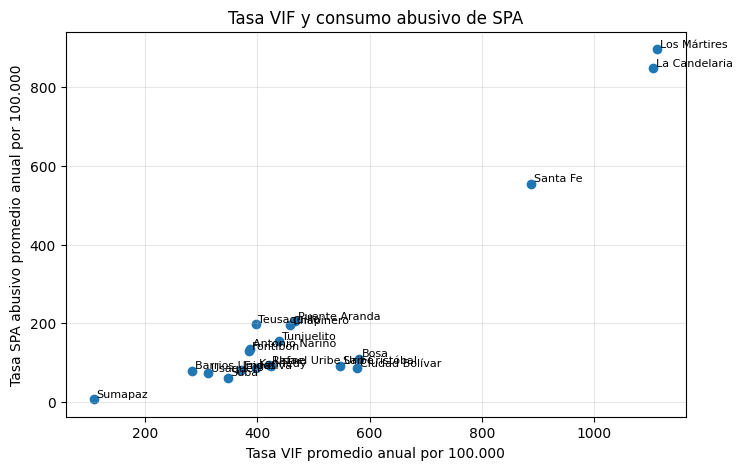

In [16]:
# Gráfico 3: Tasa VIF vs tasa SPA abusivo
plt.figure(figsize=(8, 5))
plt.scatter(base_integrada["vif_tasa_prom_anual_100k"], base_integrada["spa_abusivo_tasa_prom_anual_100k"])
for _, r in base_integrada.iterrows():
    plt.text(r["vif_tasa_prom_anual_100k"] + 5, r["spa_abusivo_tasa_prom_anual_100k"] + 5, r["localidad"], fontsize=8)
plt.xlabel("Tasa VIF promedio anual por 100.000")
plt.ylabel("Tasa SPA abusivo promedio anual por 100.000")
plt.title("Tasa VIF y consumo abusivo de SPA")
plt.grid(True, alpha=0.3)
plt.show()

## 12. Lectura técnica de resultados estadísticos

Esta celda genera una interpretación prudente para usar en nota técnica, presentación o README.

In [17]:
def construir_lectura_estadistica(resultados_df):
    lineas = []
    for _, r in resultados_df.iterrows():
        lineas.append(
            f"{r['prueba']}: Spearman rho={r['spearman_rho']} "
            f"(IC95% bootstrap: {r['spearman_ci95_inf_bootstrap']} a {r['spearman_ci95_sup_bootstrap']}), "
            f"p={r['spearman_p_value']}. La asociación es {r['fuerza_spearman']} y la lectura es: {r['interpretacion']}."
        )
    return "\n".join(lineas)

lectura_estadistica = construir_lectura_estadistica(resultados_estadisticos)
print(lectura_estadistica)
print("\nNota: estos resultados no prueban causalidad. Sirven para orientar revisión territorial y priorización analítica.")

Índice VIF vs índice contexto: Spearman rho=0.549 (IC95% bootstrap: 0.08 a 0.831), p=0.0122. La asociación es moderada y la lectura es: asociación estadísticamente significativa al 5%.
Tasa VIF vs tasa lesiones: Spearman rho=0.797 (IC95% bootstrap: 0.458 a 0.94), p=3e-05. La asociación es alta y la lectura es: asociación estadísticamente significativa al 5%.
Tasa VIF vs tasa SPA abusivo: Spearman rho=0.734 (IC95% bootstrap: 0.327 a 0.935), p=0.00023. La asociación es alta y la lectura es: asociación estadísticamente significativa al 5%.
Índice VIF vs tasa lesiones: Spearman rho=0.553 (IC95% bootstrap: 0.103 a 0.824), p=0.01137. La asociación es moderada y la lectura es: asociación estadísticamente significativa al 5%.
Índice VIF vs tasa SPA abusivo: Spearman rho=0.493 (IC95% bootstrap: -0.014 a 0.812), p=0.02711. La asociación es moderada y la lectura es: asociación estadísticamente significativa al 5%.

Nota: estos resultados no prueban causalidad. Sirven para orientar revisión territ

## 13. Exportación de resultados

Se generan archivos trazables para el repositorio:

- `base_integrada_localidad_2018_2025.csv`
- `resultados_pruebas_estadisticas.csv`
- `validaciones_calidad.csv`
- `lectura_estadistica.txt`

In [18]:
# Columnas principales para entrega
columnas_entrega = [
    "localidad", "poblacion_ref",
    "vif_casos_2018_2025", "vif_tasa_prom_anual_100k", "vif_persistencia_anios", "pct_mujeres_nna_vif",
    "lesiones_casos_2018_2025", "lesiones_tasa_prom_anual_100k",
    "spa_abusivo_casos_2018_2025", "spa_abusivo_tasa_prom_anual_100k",
    "indice_vif_familiar", "indice_contexto", "brecha_vif_contexto",
    "rank_vif_carga_calc", "rank_vif_tasa_calc", "rank_vif_familiar_calc",
    "nivel_vif_familiar", "nivel_contexto"
]
columnas_entrega = [c for c in columnas_entrega if c in base_integrada.columns]

base_export = base_integrada[columnas_entrega].copy()
base_export.to_csv(OUTPUT_DIR / "base_integrada_localidad_2018_2025.csv", index=False, encoding="utf-8-sig")
resultados_estadisticos.to_csv(OUTPUT_DIR / "resultados_pruebas_estadisticas.csv", index=False, encoding="utf-8-sig")
validaciones.to_csv(OUTPUT_DIR / "validaciones_calidad.csv", index=False, encoding="utf-8-sig")
(OUTPUT_DIR / "lectura_estadistica.txt").write_text(lectura_estadistica, encoding="utf-8")

print("Archivos exportados en:", OUTPUT_DIR)
for p in sorted(OUTPUT_DIR.glob("*")):
    print("-", p.name)

Archivos exportados en: /mnt/data/outputs
- base_integrada_localidad_2018_2025.csv
- lectura_estadistica.txt
- resultados_pruebas_estadisticas.csv
- validaciones_calidad.csv


## 14. Actualización del HTML con DATA limpio

Esta sección reemplaza el `const DATA = [...]` del HTML con la base integrada limpia. Así se evita el problema de campos duplicados y se garantiza que el visor use los resultados reproducidos.

In [19]:
def actualizar_html_con_data_limpia(html_path, df_final, output_path):
    html_path = Path(html_path)
    output_path = Path(output_path)
    texto = html_path.read_text(encoding="utf-8")

    columnas_vis = [
        "localidad", "poblacion_ref",
        "vif_casos_2018_2025", "vif_tasa_prom_anual_100k", "vif_persistencia_anios", "pct_mujeres_nna_vif",
        "lesiones_casos_2018_2025", "lesiones_tasa_prom_anual_100k",
        "spa_abusivo_casos_2018_2025", "spa_abusivo_tasa_prom_anual_100k",
        "indice_vif_familiar", "indice_contexto", "brecha_vif_contexto",
        "rank_vif_carga", "rank_vif_tasa", "rank_vif_familiar",
        "rank_vif_carga_calc", "rank_vif_tasa_calc", "rank_vif_familiar_calc",
        "nivel_vif_familiar", "nivel_contexto", "tipo_decision", "alerta_lectura", "accion_sugerida", "lectura_breve", "lectura_breve_final"
    ]
    columnas_vis = [c for c in columnas_vis if c in df_final.columns]
    data_limpia = df_final[columnas_vis].copy()

    # El visor original espera rank_vif_carga, rank_vif_tasa y rank_vif_familiar.
    for a, b in [("rank_vif_carga", "rank_vif_carga_calc"), ("rank_vif_tasa", "rank_vif_tasa_calc"), ("rank_vif_familiar", "rank_vif_familiar_calc")]:
        if a not in data_limpia.columns and b in data_limpia.columns:
            data_limpia[a] = data_limpia[b]

    # Limpieza de duplicados de columnas antes de exportar a JSON
    data_limpia = data_limpia.loc[:, ~data_limpia.columns.duplicated(keep="last")]
    json_nuevo = data_limpia.to_json(orient="records", force_ascii=False)
    texto_nuevo = re.sub(r"const\s+DATA\s*=\s*\[.*?\];", f"const DATA = {json_nuevo};", texto, flags=re.S)
    output_path.write_text(texto_nuevo, encoding="utf-8")
    return output_path

if html_path:
    html_salida = actualizar_html_con_data_limpia(html_path, base_integrada, OUTPUT_DIR / "index_actualizado_desde_notebook.html")
    print("HTML actualizado:", html_salida)
else:
    print("No se actualizó HTML porque no se encontró archivo HTML base.")

HTML actualizado: /mnt/data/outputs/index_actualizado_desde_notebook.html


## 15. Checklist final para entrega

Este bloque resume el estado técnico del producto.

In [20]:
checklist_final = {
    "modo_procesamiento": MODO_PROCESAMIENTO,
    "periodo": f"{ANIO_INICIO}-{ANIO_FIN}",
    "anios_analisis": ANIOS_ANALISIS,
    "n_localidades": int(len(base_integrada)),
    "total_vif": int(round(base_integrada["vif_casos_2018_2025"].sum())),
    "persistencia_maxima": int(base_integrada["vif_persistencia_anios"].max()),
    "json_duplicado_en_html": int(len(duplicados_json)),
    "validaciones_ok": bool(validaciones["ok"].all()),
    "pruebas_estadisticas_exportadas": True,
    "html_actualizado_exportado": bool(html_path),
}

pd.DataFrame([checklist_final]).T.rename(columns={0: "valor"})

,valor
modo_procesamiento,html_validado
periodo,2018-2025
anios_analisis,8
n_localidades,20
total_vif,283773
persistencia_maxima,8
json_duplicado_en_html,0
validaciones_ok,True
pruebas_estadisticas_exportadas,True
html_actualizado_exportado,True


## 16. Texto recomendado para README o nota técnica

> El procesamiento se desarrolló mediante un notebook reproducible en Python. Las fuentes se integraron por localidad y periodo, sin sumar registros entre fenómenos. Para VIF se calcularon casos acumulados, tasa promedio anual por 100.000 habitantes, persistencia anual sobre la mediana de localidades y participación de mujeres/NNA. Lesiones personales y consumo abusivo de SPA se usaron como señales de contexto territorial, no como componentes causales ni como registros acumulables a VIF. El índice VIF combina tasa, persistencia, participación de mujeres/NNA y volumen de casos. El índice de contexto combina tasas de lesiones y SPA. La brecha corresponde a índice VIF menos índice de contexto. Adicionalmente, se aplicaron pruebas exploratorias de asociación territorial mediante Spearman, Kendall, Pearson y bootstrap, interpretadas únicamente como evidencia exploratoria para priorización y no como causalidad.